# 📝 오늘의 과제

오늘 만든 **end-to-end 파이프라인**을 정리해 GitHub 포트폴리오에 제출합니다. 이번 과제는 *모듈 종합 프로젝트*이라 8일간의 학습이 한 폴더로 마무리됩니다.

## 제출물

1. 빵셀러 종합 프로젝트을 끝까지 수행한 노트북(`.ipynb`)
2. 노트북 마지막에 **종합 프로젝트 보고서**(5개 항목) 마크다운 셀
3. 정제·변환 결과의 **Parquet 파일** 2개 (월·매장 / 상품별 KPI)
4. 결정 로그 표(마크다운 또는 DataFrame `to_markdown()` 출력)

## 필수 과제

- [ ] `quality_report_full()` 함수를 빵셀러 데이터에 적용한 결과를 노트북에 포함했다.
- [ ] 정제 5단계를 *작은 함수*로 나누고 `.pipe()`로 묶었다.
- [ ] `bakery_clean`을 Parquet으로 저장하고, 같은 데이터를 CSV로도 저장해 *용량 차이*를 한 줄로 적었다.
- [ ] 결정 로그 표(5단계 이상)를 채워 노트북에 박았다.
- [ ] 종합 프로젝트 보고서 5개 항목을 모두 채웠다.

## 심화 과제 (선택)

- [ ] `full_pipeline()`을 *모듈*(`.py` 파일)로 분리하고, 노트북에서는 `from pipeline import full_pipeline`으로 호출했다.
- [ ] 결정 로그 함수(`log_decision`)를 각 단계 함수 내부에서 자동 호출하도록 리팩터링했다.
- [ ] (선택) 같은 파이프라인을 **Polars** 로도 작성해 두 도구의 속도를 비교했다.

## 제출 방법 (GitHub)

이번 주는 PR 흐름을 권장합니다. 학습자 개인 공개 repo에 다음 구조로 올립니다.

```text
{학습자}/ai-data-bootcamp/
└── D009/
    ├── D009_capstone.ipynb
    ├── pipeline.py          # 심화 선택
    ├── outputs/
    │   ├── bakery_store_month.parquet
    │   └── bakery_item_kpi.parquet
    └── README.md            # 보고서를 README로 옮겨도 좋습니다
```

```bash
# 작업 브랜치에서 PR로 main에 제출
git checkout -b feature/d009-capstone
git add D009/
git commit -m "D009 종합 프로젝트: end-to-end 정제·변환·저장 파이프라인"
git push -u origin feature/d009-capstone
# GitHub UI에서 main으로 PR 생성, 강사가 줄 단위 리뷰
```

## 평가 기준

| 축 | 무엇을 보나 |
| --- | --- |
| 정확성 | 파이프라인이 처음부터 끝까지 오류 없이 실행되는가 |
| 합리성 | 각 결정의 *근거*가 코드 옆에 글로 남아 있는가 |
| 재사용성 | 함수가 *데이터에 의존하지 않게* 작성되었는가 |
| 산출물 품질 | Parquet·README·결정 로그가 GitHub에서 잘 보이는가 |

> 💡 모두의연구소의 과제는 순위를 매기지 않습니다. **"어제의 나보다 데이터를 더 신뢰할 수 있게 정제했는가"** 가 기준이에요. 이번 종합 프로젝트은 8일간의 성장을 한눈에 보여주는 산출물이 될 거예요.

---

수고하셨습니다! 🎉

오늘 여러분은 8일간 흩어져 있던 도구들을 **하나의 파이프라인**으로 묶었습니다. 더 중요한 건, *왜 그렇게 묶었는지*를 글로 남기는 습관을 들였다는 점입니다. 같은 코드를 6개월 뒤에 봐도, 동료가 처음 봐도, *결정의 흐름*이 그대로 살아 있는 노트북 — 그것이 데이터 분석가의 *진짜 산출물*입니다.

다음 모듈에서는 *그 파이프라인의 윗단*, 즉 데이터를 직접 구해 오는 **웹 스크래핑**에서 만나요. 천천히, 그러나 멈추지 않고 가봅시다. 🚀

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 교안은 생성형 AI를 활용해 제작하고 제작자가 검수했습니다.<br>
무단 복제 및 배포를 금합니다.</sub>

In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn pyarrow -q

import os
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\cehha\ai-data-bootcamp\D009\d009_outputs


In [5]:
# 종합 프로젝트용 새 데이터 생성 — 베이커리 체인 "빵셀러" 운영 데이터
np.random.seed(13)
n_days = 90
n_stores = 6
n_rows = n_days * n_stores * 4   # 매장 x 일자 x 시간대(4구간)

stores = [f"S{i:02d}" for i in range(1, n_stores + 1)]
items = ["크루아상", "식빵", "케이크", "샌드위치", "쿠키"]

bakery = pd.DataFrame({
    "store_id": np.tile(stores, n_rows // n_stores)[:n_rows],
    "date_str": np.random.choice([
        "2025-04-01", "2025/04/01", "20250401",
        "2025-05-15", "2025/05/15", "20250515",
        "2025-06-20", "2025/06/20", "20250620",
    ], n_rows),
    "item": np.random.choice(items, n_rows),
    "quantity": np.random.choice([1, 1, 2, 2, 3, 5, 50], n_rows),  # 50은 의심값
    "unit_price": np.random.choice([3500, 4500, 5500, 8500, 12000], n_rows),
})
bakery["revenue"] = bakery["quantity"] * bakery["unit_price"]

# 오염 심기
bakery.loc[np.random.choice(n_rows, 60, replace=False), "revenue"] = np.nan
bakery.loc[5, "revenue"] = -45000  # 환불 또는 실수
bakery.loc[bakery.sample(10, random_state=1).index, "store_id"] = " S01 "  # 공백
bakery.loc[bakery.sample(8, random_state=2).index, "item"] = "케익"        # 표기 혼재('케이크' vs '케익')
bakery = pd.concat([bakery, bakery.iloc[[0, 1, 2, 3]]], ignore_index=True)   # 중복 4건

print("빵셀러 데이터 생성 완료:", bakery.shape)
bakery.head()

빵셀러 데이터 생성 완료: (2164, 6)


,store_id,date_str,item,quantity,unit_price,revenue
0,S01,20250401,쿠키,2,12000,24000.0
1,S02,2025-04-01,케이크,2,12000,24000.0
2,S03,2025-04-01,쿠키,1,5500,5500.0
3,S04,2025-06-20,쿠키,2,8500,17000.0
4,S05,20250401,샌드위치,5,4500,22500.0


[품질 리포트(완전판)] bakery
  행 수: 2,164  /  열 수: 6
  완전 중복 행: 321건
              dtype  missing  missing_pct  n_unique  outlier_pct_iqr  \
store_id        str        0         0.00         7              NaN   
date_str        str        0         0.00         9              NaN   
item            str        0         0.00         6              NaN   
quantity      int64        0         0.00         5            14.56   
unit_price    int64        0         0.00         5             0.00   
revenue     float64       60         2.77        26            17.30   

            maybe_datetime  
store_id             False  
date_str             False  
item                 False  
quantity             False  
unit_price           False  
revenue              False  


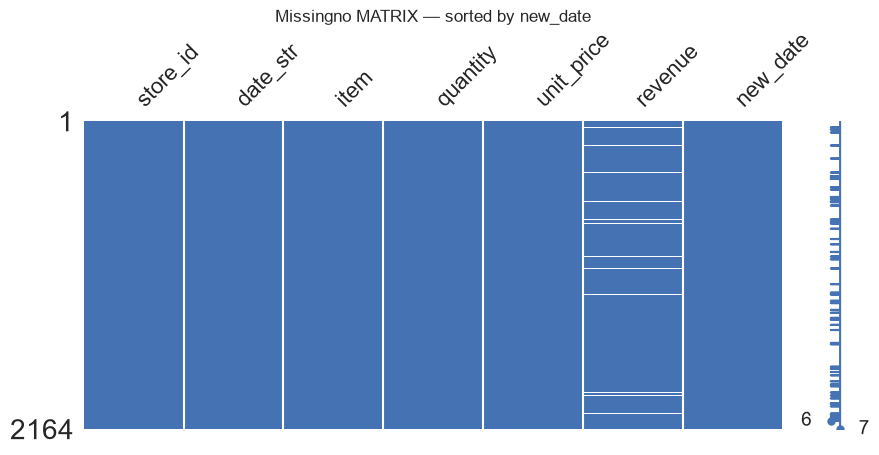

In [6]:
# 품질 리포트 함수 
import missingno as msno
pd.set_option("display.max_rows", None)

def quality_report_full(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    n_rows = len(df)
    base = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    base["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    # object 컬럼이 실제로는 날짜로 파싱되는지 의심 표시
    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    base["maybe_datetime"] = base.index.isin(suspicious_datetime)

    print(f"[품질 리포트(완전판)] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return base


qr_orders_full = quality_report_full(bakery, "bakery")
print(qr_orders_full)


bakery_copy = bakery.copy()
bakery_copy["new_date"] = pd.to_datetime(bakery_copy["date_str"], format="mixed", errors="coerce")
# 데이터 사본 생성 후 date_str을 날짜형식으로 변경
sorted_bakery_raw = bakery_copy.sort_values("new_date")
msno.matrix(sorted_bakery_raw, color=(0.27, 0.45, 0.70), figsize=(10, 4))
plt.title("Missingno MATRIX — sorted by new_date")
plt.show()
# 날짜 기준으로 정렬한 뒤 revenue 결측값의 시계열적 위치 확인, 특정 시기에 몰리지 않고 랜덤하게 발생 (MCAR 추정)

In [ ]:
# revenue, quantity의 이상치 확인
def show_outliers(df, col):
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return df[(df[col] < lo) | (df[col] > hi)]

outliers_quantity = show_outliers(bakery, "quantity").sort_values("quantity", ascending=False)
outliers_revenue = show_outliers(bakery, "revenue").sort_values("revenue", ascending=False)

outliers_quantity.groupby("store_id").size().sort_values(ascending=False)
outliers_revenue.groupby("store_id").size().sort_values(ascending=False)

store_id
S02      64
S06      63
S01      60
S04      59
S03      59
S05      57
 S01      2
dtype: int64

In [22]:
# 데이터 정제 (중복 - 문자열 - 날짜 - 이상치 - 결측치 순서대로 정제하기)
print(bakery.describe()) # 숫자 형식 칼럼들 내 최대값, 죄소값 체크
print(bakery.duplicated().sum()) #bakery 내 중복 행 개수 확인, 첫번째 중복값은 제외
bakery[bakery.duplicated(keep="first")] #bakery 내 중복 행 확인, 첫번째 중복값은 제외

for col in bakery.select_dtypes(include="object").columns: 
    print(f"--{col}--")
    print(bakery[col].unique())
    print()
#bakery 내 object 칼럼의 unique 값 확인, 확인결과 store_id, item 칼럼에서 공백 및 표기 통일 필요, date_str 칼럼은 to.datetime 적용 필요

numeric_cols = bakery.select_dtypes(include="number").columns
print(numeric_cols)

def b_ddrop(df): return df.drop_duplicates().reset_index(drop=True)
def b_strip_store_id(df): return df.assign(store_id=df["store_id"].str.strip())
def b_item_replace(df): return df.assign(item=df["item"].replace({"케익" : "케이크"}))
def b_parse_date(df): return df.assign(date=pd.to_datetime(df["date_str"], format="mixed", errors="coerce")).drop(columns=["date_str"])

                                       
refunds_bakery = bakery[bakery["revenue"] < 0 ].copy()

bakery_clean = (
    bakery
    .pipe(b_ddrop) # 중복행 드랍
    .pipe(b_strip_store_id) # store_id 칼럼
    .pipe(b_item_replace) # item 칼럼 표기 통일
    .pipe(b_parse_date) # 날짜형식으로 파싱
    .pipe(lambda d: d[d["revenue"] >= 0]) # revenue 항목 내 0이상인 값 필터링
    .pipe(lambda d: d.dropna(subset=["revenue"])) # revenue 칼럼 내 결측값 드랍
    .reset_index(drop=True)
)

print(len(bakery_clean))
print()
print(refunds_bakery)
print()
print(bakery_clean["store_id"].unique())
print()
print(bakery_clean["item"].unique())



          quantity    unit_price        revenue
count  2164.000000   2164.000000    2104.000000
mean      9.249538   6775.878004   64157.557034
std      16.868632   3080.016334  132558.433306
min       1.000000   3500.000000  -45000.000000
25%       1.000000   4500.000000    8500.000000
50%       2.000000   5500.000000   13500.000000
75%       5.000000   8500.000000   25500.000000
max      50.000000  12000.000000  600000.000000
321
--store_id--
<ArrowStringArray>
['S01', 'S02', 'S03', 'S04', 'S05', 'S06', ' S01 ']
Length: 7, dtype: str

--date_str--
<ArrowStringArray>
[  '20250401', '2025-04-01', '2025-06-20', '2025/05/15', '2025-05-15',
   '20250515', '2025/04/01',   '20250620', '2025/06/20']
Length: 9, dtype: str

--item--
<ArrowStringArray>
['쿠키', '케이크', '샌드위치', '크루아상', '식빵', '케익']
Length: 6, dtype: str

Index(['quantity', 'unit_price', 'revenue'], dtype='str')
1784

  store_id    date_str  item  quantity  unit_price  revenue
5      S06  2025/05/15  샌드위치         5        4500 -45000

In [24]:
OUT_DIR = Path("outputs") 

csv_path = OUT_DIR / "bakery_clean.csv"
parquet_path = OUT_DIR / "bakery_clean.parquet"

bakery_clean.to_csv(csv_path, index=False)
bakery_clean.to_parquet(parquet_path, index=False)

print("저장 완료!")
print("CSV     :", csv_path)
print("Parquet :", parquet_path)


저장 완료!
CSV     : outputs\bakery_clean.csv
Parquet : outputs\bakery_clean.parquet


In [12]:
# 월별·매장별 매출 KPI(피벗테이블)
bakery_clean["month"] = bakery_clean["date"].dt.to_period("M").astype(str)
store_month = bakery_clean.pivot_table(
    index="store_id", columns="month", values="revenue",
    aggfunc="sum", fill_value=0, margins=True, margins_name="합계"
).round(0)

print("월별·매장별 매출:")
display(store_month)

# 상품별 평균 단가 및 총매출 KPI
item_kpi = (
    bakery_clean.groupby("item")
    .agg(avg_price=("unit_price", "mean"), total_revenue=("revenue", "sum"), n_orders=("revenue", "count"))
    .round(0)
    .sort_values("total_revenue", ascending=False)
)
item_kpi.loc["합계"] = {
    "avg_price": bakery_clean["unit_price"].mean().round(1),
    "total_revenue": bakery_clean["revenue"].sum().round(1),
    "n_orders": bakery_clean["revenue"].count()
}

print("\n상품별 KPI:")
display(item_kpi)

월별·매장별 매출:


month,2025-04,2025-05,2025-06,합계
store_id,,,,
S01,6834000.0,7243500.0,5884000.0,19961500.0
S02,7531500.0,6768500.0,7996500.0,22296500.0
S03,7424500.0,4548000.0,7297500.0,19270000.0
S04,6471500.0,7105000.0,6744500.0,20321000.0
S05,8681500.0,4102000.0,4960000.0,17743500.0
S06,9156000.0,5095500.0,6796500.0,21048000.0
합계,46099000.0,34862500.0,39679000.0,120640500.0



상품별 KPI:


,avg_price,total_revenue,n_orders
item,,,
쿠키,6878.0,26690000.0,365
샌드위치,6555.0,26297000.0,370
케이크,6859.0,23788500.0,359
식빵,6555.0,22997500.0,355
크루아상,6946.0,20867500.0,335
합계,6755.9,120640500.0,1784


In [ ]:
from pathlib import Path

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

store_month.to_parquet(OUT_DIR / "store_month.parquet")
item_kpi.to_parquet(OUT_DIR / "item_kpi.parquet")

print("저장 완료!")

저장 완료!


# 빵셀러 데이터 정제·집계 보고서

## 1. 데이터 개요
- 출처: (가상) 빵셀러 베이커리 체인 운영 로그
- 기간: 2025-04-01 ~ 2025-06-30 (3개월)
- 원본 행 수 / 정제 후 행 수: 2164행 → 1784행

## 2. 발견한 품질 문제
- 결측: revenue 칼럼 내 60개 행(2.77%)
- 중복: 321건
- 이상치: R
- 표기 혼재: item 칼럼 내 "케이크", "케익" 표기 혼재 / store_id 칼럼 내 "S01", " S01 " 표기 혼재

## 3. 처리 결정과 근거 (5줄로)
1. 중복 행 321건: 중복 행 중 첫 중복값을 제외한 추가 중복행들에 대해 삭제작업 진행
2. store_id 공백: strip 함수 사용하여 공백값 삭제, "S01"로 표기 통일
3. item '케익' → '케이크': replace 함수 사용하여 "케익" 표기 "케이크"로 통일
4. revenue 음수: 별도 보관 1건, 환불 관련 데이터인지 내부 확인 필요
5. revenue 결측 60건 → 제거: 시계열적으로 결측값의 위치를 확인한 결과 랜덤하게 발생(MCAR 추정), 삭제 결정
6. date_str 형식 날짜형식으로 파싱: 기존 object 형식을 필터링이 가능하도록 날짜형식으로 파싱
7. 이상치(outlier) 처리: revenue, quantity에서 IQR판단 기준으로 이상치 발생. 이상치 값을 필터링 하여 추출하여 보았을 때 계산 실수 또는 오입력은 없었으며 매장별로 비교해보았을 때에도 균등하게 발생, 유지

## 4. 주요 KPI 결과 (2줄)
- (월·매장 관점) 가장 매출이 큰 매장과 그 월: 
    - 전체적으로 월간매출은 감소하는 트렌드, 합계 기준 가장 높은 매출을 기록한 매장은 S02이고 가장 매출이 높았던 달은 4월. 개별 매장 월별 퍼포먼스 기준으로는 4월 S06의 매출이 가장 높음
- (상품 관점) 매출 1위 상품: 
    - 매출액 기준 1위 상품은 쿠키로 단가가 가장 높음에도 2위의 판매량을 기록하며 최고매출 기록

## 5. 한계와 후속 작업
- 환불 데이터의 원인 분석 필요, 실제 환불데이터인지 내부적으로 확인 필요. 환불일 경우 해당 고객 ID와 제품을 기준으로 이전에 비슷한 케이스가 있었는지 분석, 비슷한 케이스가 보여질 경우 원인 파악 필요
- 후속 데이터를 보며 계절성을 반영한 매출 트렌드 확인, 프로모션 및 주변 상권 변화를 고려한 다각도 분석 필요 